In [1]:

from dask.distributed import Client
client = Client(scheduler_file='/proj/jayeon/mpi/scheduler.json')  
client

<Client: 'tcp://203.247.189.223:41175' processes=5 threads=90, memory=419.10 GiB>

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
#import pystuff as ps
import cartopy.crs as ccrs
import cartopy.feature as cf
import seaborn as sns
import matplotlib.patches as patches
from scipy import stats
import cmocean
import glob
from cmcrameri import cm
from tqdm.notebook import tqdm_notebook

In [19]:
import warnings
warnings.simplefilter(action='ignore')

In [20]:
VAR = ['hcc', 'mcc', 'lcc']
scenarios = ('TCo1279-DART-2000', 'TCo1279-DART-2030', 'TCo1279-DART-2060', 'TCo1279-DART-2090')

In [21]:
exceptcv=['time_counter','lon','lat',*VAR]
def process_coords(ds, drop=True, except_coord_vars=exceptcv):
    """Preprocessor function to drop all non-dim coords, which slows down concatenation."""
    coord_vars = []
    for v in np.array(ds.coords) :
        if not v in except_coord_vars:
            coord_vars += [v]
    for v in np.array(ds.data_vars) :
        if not v in except_coord_vars:
            coord_vars += [v]
    #ds=ds.sel(lat=slice(-90,30), lon=slice(0, 360))
    if drop:
        return ds.drop(coord_vars)
    else:
        return ds.set_coords(coord_vars)

In [22]:
file_list = []
#/proj/shared_data/awicm3/TCo1279-DART-2000/outdata/oifs/atm_remapped_1m_2t_1m_200612-200612.nc
for var in VAR:
    files = []
    for scenario in scenarios:
        in_dir = '/proj/shared_data/awicm3/' + scenario + '/outdata/oifs/atm_remapped_1m_'+var+'_1m_*.nc'
        files += glob.glob(in_dir)
    files = sorted(files)
    file_list.append(files)

for i in range(len(VAR)):
    print(i, VAR[i], len(file_list[i]))

0 hcc 480
1 mcc 480
2 lcc 480


In [23]:
ds0=xr.open_mfdataset(file_list[0],chunks={'time':30},combine='nested',concat_dim='time_counter', parallel='True',
                      preprocess=process_coords,decode_cf=True,decode_times=True)
ds1=xr.open_mfdataset(file_list[1],chunks={'time':30},combine='nested',concat_dim='time_counter', parallel='True',
                      preprocess=process_coords,decode_cf=True,decode_times=True)
ds2=xr.open_mfdataset(file_list[2],chunks={'time':30},combine='nested',concat_dim='time_counter', parallel='True',
                      preprocess=process_coords,decode_cf=True,decode_times=True)

In [24]:
file=xr.open_mfdataset('/proj/daewon/AWI-CM3_daewon/cdo_reamp_analysis/Timeseries_WS.nc')

In [25]:
file

<xarray.Dataset>
Dimensions:    (year: 151, t_siv_sep: 151, t_siv_feb: 151, t_ohc: 151,
                t_lcc: 151, t_fh: 151, t_ssr: 151, t_sshf: 151, t_slhf: 151)
Coordinates:
  * year       (year) float64 1.95e+03 1.951e+03 1.952e+03 ... 2.099e+03 2.1e+03
  * t_siv_sep  (t_siv_sep) float64 2.555e+03 2.668e+03 2.921e+03 ... 19.39 7.018
  * t_siv_feb  (t_siv_feb) float64 343.8 103.4 87.31 228.5 ... 0.0 0.0 0.0 0.0
  * t_ohc      (t_ohc) float64 1.41e+22 1.427e+22 ... 2.484e+22 2.519e+22
  * t_lcc      (t_lcc) float64 1.773e+08 1.752e+08 ... 1.667e+08 1.632e+08
  * t_fh       (t_fh) float64 -4.379e+13 -5.091e+13 ... 2.809e+13 4.987e+13
  * t_ssr      (t_ssr) float64 2.471e+14 2.376e+14 ... 3.612e+14 3.687e+14
  * t_sshf     (t_sshf) float64 -2.467e+13 -2.095e+13 ... -3.58e+13 -2.627e+13
  * t_slhf     (t_slhf) float64 -7.807e+13 -7.661e+13 ... -1.227e+14 -1.179e+14
Data variables:
    *empty*

In [26]:
ds0['h']  = ds0['hcc']
ds0       = ds0.drop(['hcc'])

ds1['m']  = ds1['mcc']
ds1       = ds1.drop(['mcc'])

ds2['l']  = ds2['lcc']
ds2       = ds2.drop(['lcc'])

In [27]:
import pandas as pd
ds0['time_counter'] = pd.to_datetime(ds0['time_counter'])
ds0 = ds0.sortby('time_counter')

ds1['time_counter'] = pd.to_datetime(ds1['time_counter'])
ds1 = ds1.sortby('time_counter')

ds2['time_counter'] = pd.to_datetime(ds2['time_counter'])
ds2 = ds2.sortby('time_counter')

In [32]:
#-------Climatology---------------------
h_2000 = (ds0.h).sel(time_counter=slice('2002', '2012')).mean('time_counter').squeeze().load()
h_2030 = (ds0.h).sel(time_counter=slice('2032', '2036')).mean('time_counter').squeeze().load()
h_2060 = (ds0.h).sel(time_counter=slice('2062', '2067')).mean('time_counter').squeeze().load()
h_2090 = (ds0.h).sel(time_counter=slice('2092', '2099')).mean('time_counter').squeeze().load()

In [33]:
#-------Climatology---------------------
m_2000 = (ds1.m).sel(time_counter=slice('2002', '2012')).mean('time_counter').squeeze().load()
m_2030 = (ds1.m).sel(time_counter=slice('2032', '2036')).mean('time_counter').squeeze().load()
m_2060 = (ds1.m).sel(time_counter=slice('2062', '2067')).mean('time_counter').squeeze().load()
m_2090 = (ds1.m).sel(time_counter=slice('2092', '2099')).mean('time_counter').squeeze().load()

In [34]:
#-------Climatology---------------------
l_2000 = (ds2.l).sel(time_counter=slice('2002', '2012')).mean('time_counter').squeeze().load()
l_2030 = (ds2.l).sel(time_counter=slice('2032', '2036')).mean('time_counter').squeeze().load()
l_2060 = (ds2.l).sel(time_counter=slice('2062', '2067')).mean('time_counter').squeeze().load()
l_2090 = (ds2.l).sel(time_counter=slice('2092', '2099')).mean('time_counter').squeeze().load()

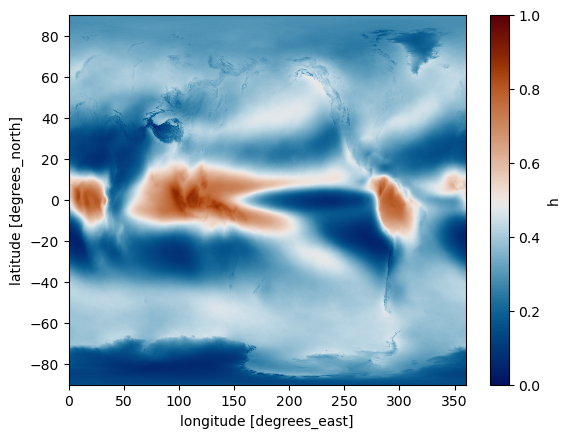

In [35]:
h_2000.plot(vmin=0, vmax=1, cmap=cm.vik)

In [36]:
#--- Temperature signal normalized with respect to a 1 degree Celsius global mean temperature change
h_C1 = (h_2030 - h_2000)/1.11
h_C2 = (h_2060 - h_2000)/2.90
h_C3 = (h_2090 - h_2000)/4.93

h_scaling = (h_C1 + h_C2 + h_C3)/3

In [37]:
#--- Precipitationsignal normalized with respect to a 1 degree Celsius global mean temperature change
m_C1 = (m_2030 - m_2000)/1.11
m_C2 = (m_2060 - m_2000)/2.90
m_C3 = (m_2090 - m_2000)/4.93

m_scaling = (m_C1 + m_C2 + m_C3)/3

In [38]:
#--- WindSpeed signal normalized with respect to a 1 degree Celsius global mean temperature change
l_C1 = (l_2030 - l_2000)/1.11
l_C2 = (l_2060 - l_2000)/2.90
l_C3 = (l_2090 - l_2000)/4.93

l_scaling = (l_C1 + l_C2 + l_C3)/3

  0%|          | 0/6 [00:00<?, ?it/s]

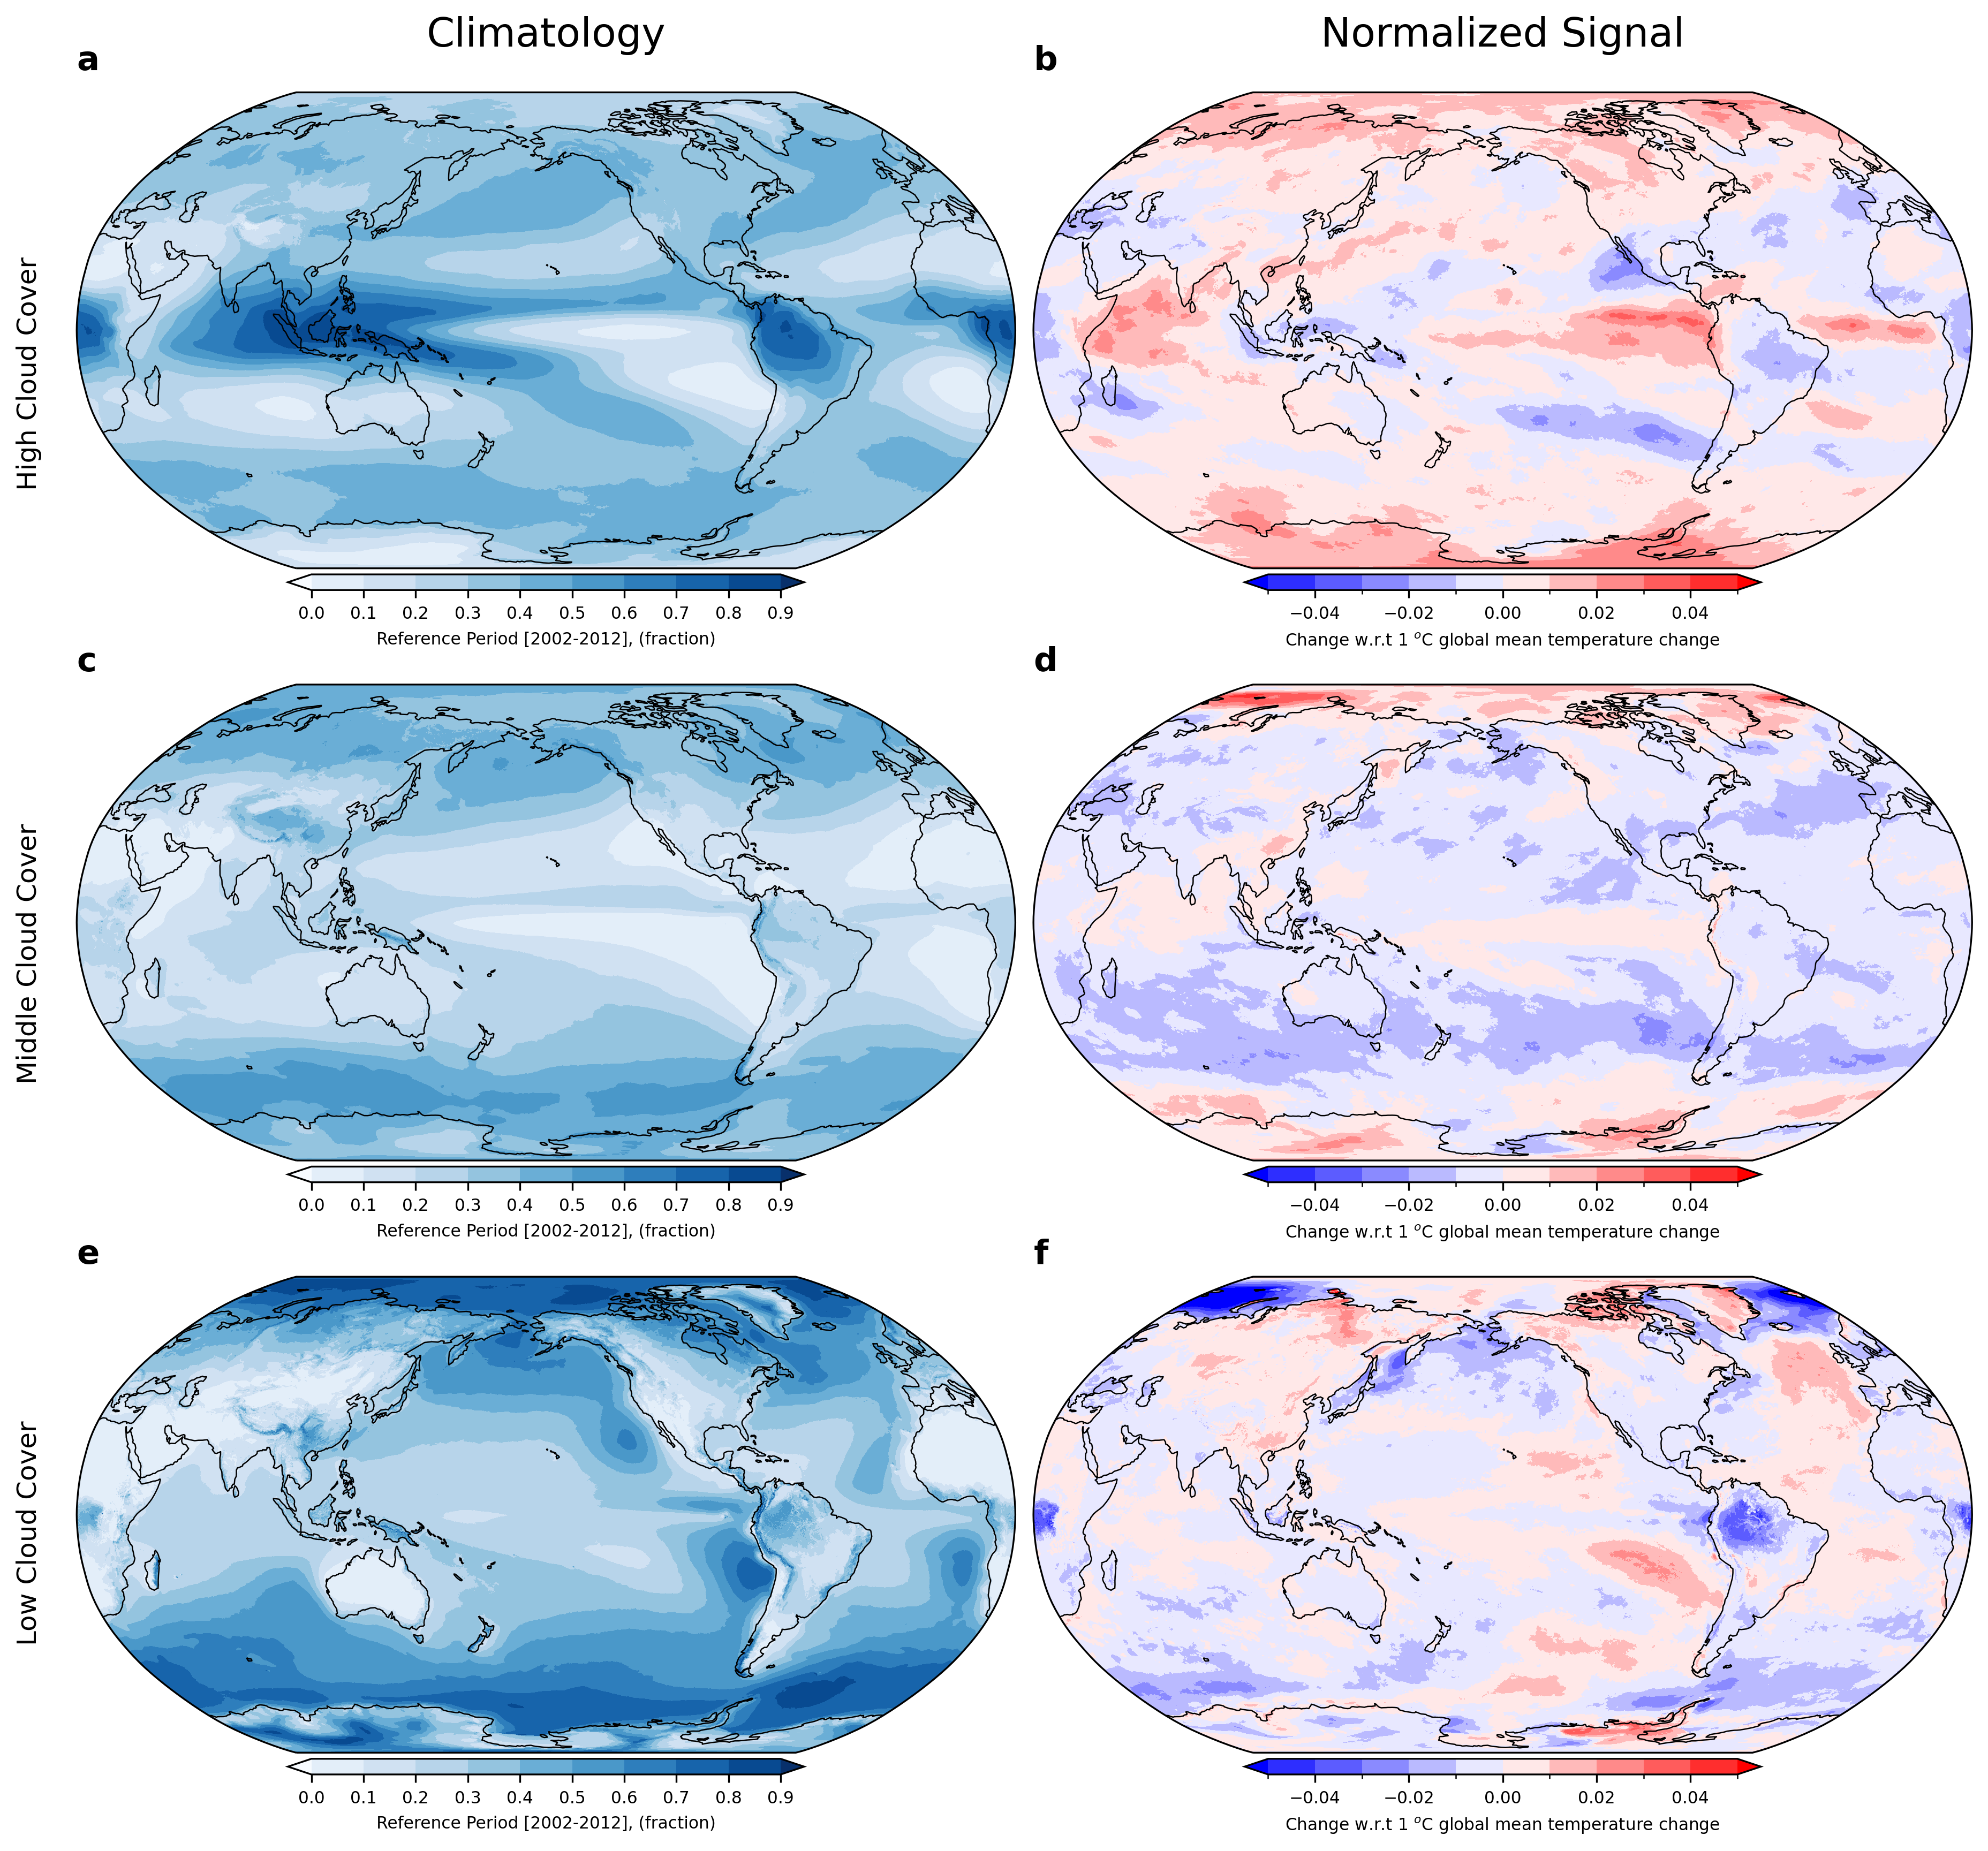

In [59]:
plt.rcParams.update({'font.size': 7.5})
fig,ax = plt.subplots(3,2,figsize=(18.5, 19), dpi=300, facecolor='w', edgecolor='k',subplot_kw={'projection': ccrs.Robinson(central_longitude=200)})

import cmocean
titlesM = ['Climatology', 'Normalized Signal']
titlesL = ['$\mathbf{a}$', '$\mathbf{b}$', '$\mathbf{c}$', '$\mathbf{d}$', '$\mathbf{e}$', '$\mathbf{f}$']
labels = ['High Cloud Cover', 'Middle Cloud Cover', 'Low Cloud Cover']

fields=[ h_2000,  h_scaling, 
         m_2000, m_scaling,  
         l_2000, l_scaling]

levels=[np.arange(0,1,0.1), np.arange(-0.05,0.06,0.01), 
        np.arange(0,1,0.1), np.arange(-0.05,0.06,0.01),  
        np.arange(0,1,0.1), np.arange(-0.05,0.06,0.01)]
cbar=['Blues', 'bwr',
      'Blues', 'bwr',   
      'Blues', 'bwr']
units=[ 'Reference Period [2002-2012], (fraction)', 'Change w.r.t 1 $^{o}$C global mean temperature change',
        'Reference Period [2002-2012], (fraction)', 'Change w.r.t 1 $^{o}$C global mean temperature change', 
        'Reference Period [2002-2012], (fraction)', 'Change w.r.t 1 $^{o}$C global mean temperature change', ]

for i,a in enumerate(tqdm_notebook(ax.flat)) :
      clabel=('%s'%units[i])
      cbar_kwargs={'orientation':'horizontal','pad':0.01,'shrink':0.55, 'label':clabel, 'aspect':33}
      fields[i].plot.contourf(ax=a,transform=ccrs.PlateCarree(),levels=levels[i],cbar_kwargs=cbar_kwargs,cmap=cbar[i], extend='both')
      a.coastlines(linewidth=0.6,color='black')
      a.set_global()  

for  i, label in enumerate(labels):
    fig.text(0.29, 0.85 - i * 0.19, label, transform=fig.transFigure, fontsize=12, va='center', ha='center', rotation=90)
    
for i, a in enumerate(ax.flat):
    a.set_title('%s' % titlesL[i], size=15, loc='left')

    if i <= 1:
        a.set_title('%s' % (titlesM[i]), size=18, y=1.05, pad=10)
    else:
        a.set_title('')
            
plt.tight_layout(rect=[0.3, 0.36, 0.95, 0.97])
plt.savefig('/proj/jayeon/vienna2024/cloudcover_changes.png',dpi=500, bbox_inches = 'tight')